In [1]:
import pandas as pd
import numpy as np
import matplotlib
from numpy.ma.core import shape

para ler arquivos, nos temos algumas funçoes

In [5]:
#read_csv que le arquivos csv e txt
df = pd.read_csv("AprendizadoPandas.txt")

In [6]:
df

,Nome,idade,altura,sexo,profissao
0,Guilherme,27,1.82,M,Programador
1,Cassiane,22,1.57,F,Diretora
2,Filipe,28,1.60,M,Programador
3,Joao,27,1.80,M,Programador
4,Vitor,28,1.83,M,Programador
5,Gabriela,29,1.58,F,Gerente De Loja
6,Juliana,42,1.59,F,Professora
7,Luciana,23,1.67,F,Enfermeira
8,Steve,32,1.90,M,Sargento
9,Amanda,25,1.60,F,Medica


Funcionou sem problema a leitura do arquivo, isso acontece, pois
o read_csv usa como separador o "," e como o nosso txt tinha ","
como separador logo nao deu problema.
Vamos testar usando um outro arquivo com um separador diferente

In [7]:
with open("AprendizadoPandas.txt", "r", encoding="utf-8") as fin, open("AprendizadoPandas_modificado.txt", "w", encoding="utf-8") as fout:
    fout.write(fin.read().replace(",", "/"))


In [8]:
df2 = pd.read_csv("AprendizadoPandas_modificado.txt")

In [9]:
df2

,Nome/idade/altura/sexo/profissao
0,Guilherme/27/1.82/M/Programador
1,Cassiane/22/1.57/F/Diretora
2,Filipe/28/1.60/M/Programador
3,Joao/27/1.80/M/Programador
4,Vitor/28/1.83/M/Programador
5,Gabriela/29/1.58/F/Gerente De Loja
6,Juliana/42/1.59/F/Professora
7,Luciana/23/1.67/F/Enfermeira
8,Steve/32/1.90/M/Sargento
9,Amanda/25/1.60/F/Medica


Como voce pode ver pelo fato de termos trocado o sep, o pandas ainda achava que era "," e colocou todas as colunas juntas


Para resolver isso teriamos daus formas, uma mais eficiente que a outra.
A primeira seria passando o separador correto

Soluçao 1:

In [38]:
df2 = pd.read_csv("AprendizadoPandas_modificado.txt",sep='/')
df2

,Nome,idade,altura,sexo,profissao
0,Guilherme,27,1.82,M,Programador
1,Cassiane,22,1.57,F,Diretora
2,Filipe,28,1.60,M,Programador
3,Joao,27,1.80,M,Programador
4,Vitor,28,1.83,M,Programador
5,Gabriela,29,1.58,F,Gerente De Loja
6,Juliana,42,1.59,F,Professora
7,Luciana,23,1.67,F,Enfermeira
8,Steve,32,1.90,M,Sargento
9,Amanda,25,1.60,F,Medica


Ficou perfeita, como voce pode ver.

A outra soluçao, seria utilizarmos da engine do python, quando passamos que o separador é None e usamos a engine python, ele tenta
descobrir o separador, mas nao é perfeito

In [37]:
df2 = pd.read_csv("AprendizadoPandas_modificado.txt",sep=None,engine='python')
df2

,N,me/idade/altura/sex,/pr,fissa,Unnamed: 4
0,Guilherme/27/1.82/M/Pr,gramad,r,None,None
1,Cassiane/22/1.57/F/Diret,ra,None,None,None
2,Filipe/28/1.60/M/Pr,gramad,r,None,None
3,J,a,/27/1.80/M/Pr,gramad,r
4,Vit,r/28/1.83/M/Pr,gramad,r,None
5,Gabriela/29/1.58/F/Gerente De L,ja,None,None,None
6,Juliana/42/1.59/F/Pr,fess,ra,None,None
7,Luciana/23/1.67/F/Enfermeira,None,None,None,None
8,Steve/32/1.90/M/Sargent,NaN,None,None,None
9,Amanda/25/1.60/F/Medica,None,None,None,None


Como falei, deixar para ele chutar nao é perfeito, tanto que ele achou que o separador é a letra "o"
Deixando o nosso dataframe totalmente quebrado

In [16]:
df2

,Nome,idade,altura,sexo,profissao
0,Guilherme,27,1.82,M,Programador
1,Cassiane,22,1.57,F,Diretora
2,Filipe,28,1.60,M,Programador
3,Joao,27,1.80,M,Programador
4,Vitor,28,1.83,M,Programador
5,Gabriela,29,1.58,F,Gerente De Loja
6,Juliana,42,1.59,F,Professora
7,Luciana,23,1.67,F,Enfermeira
8,Steve,32,1.90,M,Sargento
9,Amanda,25,1.60,F,Medica


In [17]:
df2.dtypes

Nome          object
idade          int64
altura       float64
sexo          object
profissao     object
dtype: object

In [18]:
df2 = pd.read_csv("AprendizadoPandas_modificado.txt",sep="/",dtype = str)
df2
df2.dtypes

Nome         object
idade        object
altura       object
sexo         object
profissao    object
dtype: object

Criando um dataframe

In [19]:
df3 = pd.DataFrame({"a" : [4, 5, 6],
 "b" : [7, 8, 9],
 "c" : [10, 11, 12]},
 index = [1, 2, 3])
df3

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


tambem pode criar assim

In [20]:
df3 =  pd.DataFrame(
 [[4, 7, 10],
 [5, 8, 11],
 [6, 9, 12]],
 index=[1, 2, 3],
 columns=['a', 'b', 'c'])

df3

,a,b,c
1,4,7,10
2,5,8,11
3,6,9,12


In [21]:
df3 = pd.DataFrame(
 {"a" : [4 ,5, 6],
 "b" : [7, 8, 9],
 "c" : [10, 11, 12]},
index = pd.MultiIndex.from_tuples(
 [('d', 1), ('d', 2),
 ('e', 2)], names=['n', 'v']))

df3

a  b   c
n v          
d 1  4  7  10
  2  5  8  11
e 2  6  9  12

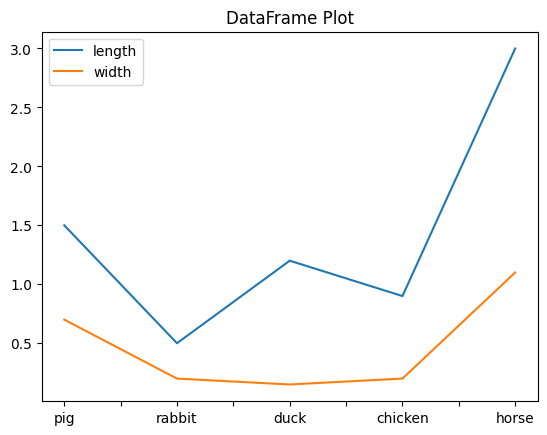

In [30]:
df5 = pd.DataFrame({'length': [1.5, 0.5, 1.2, 0.9, 3],
                  'width': [0.7, 0.2, 0.15, 0.2, 1.1]},
                  index=['pig', 'rabbit', 'duck', 'chicken', 'horse'])
plot = df5.plot(title="DataFrame Plot")

<Axes: title={'center': 'Teste'}>

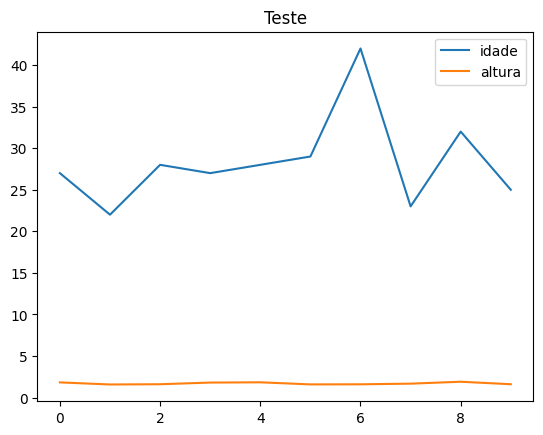

In [41]:
df2.plot(title="Teste")


<Axes: title={'center': 'Teste'}>

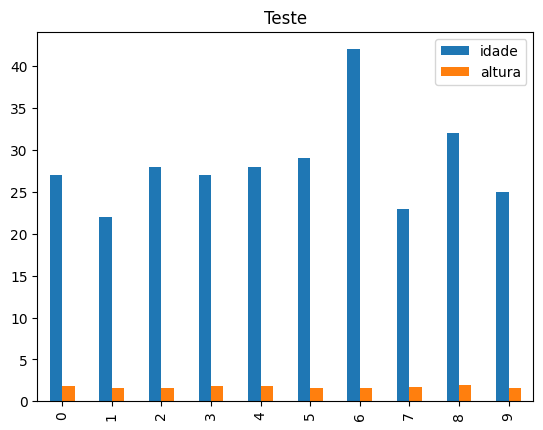

In [42]:
df2.plot(kind="bar",title="Teste")

<Axes: title={'center': 'teste'}>

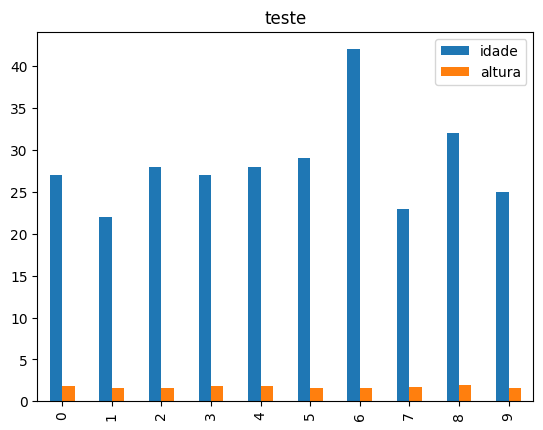

In [46]:
df2.plot.bar(title="teste")

<Axes: >

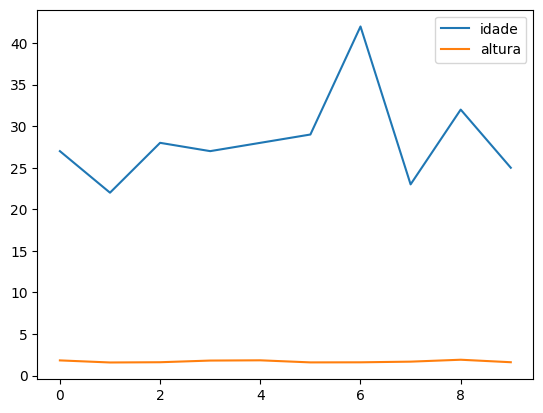

In [48]:
ax3 = pd.DataFrame.plot(data=df2)
ax3()

In [7]:
zero_array = np.zeros((2,5))
print(zero_array)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
